# SHAP: why this forecast

Same live path as notebook 04. Set `MODE` to `short` (hourly, next 24h) or `medium` (hourly, next 7 days).

Three models are explained, none of them using `mean_pred` as a feature:

- **Mean** — first-stage LightGBM. This *is* the P50 / point forecast story.
- **P10** — lower quantile, after the mean is known.
- **P90** — upper quantile, after the mean is known.

Positive SHAP pushed that output **up**; negative pushed it **down**.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import shap

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast.explain import OUTPUTS, live_explained, mean_abs_shap
from energy_forecast.modes import MODE_SPEC, resample_to_mode

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

MODE = "medium"

In [12]:
scored, shap_by_output, details = live_explained(MODE)
display_fc = resample_to_mode(scored, MODE, freq=MODE_SPEC[MODE]["display_freq"])
print(MODE, "half-hourly", len(scored), "display bins", len(details))
print(scored["model"].value_counts().to_string())
print("mean vs p50 (should be close)")
print((scored["p50"] - scored["mean_pred"]).abs().describe())
display(display_fc.head())

medium half-hourly 336 display bins 29
model
week    287
day      46
hour      3
mean vs p50 (should be close)
count   336.00
mean    183.80
std     157.19
min       2.36
25%      68.60
50%     144.88
75%     253.74
max     945.46
dtype: float64


,region_id,timestamp,lead_hours,p10,p50,p90,demand_mw,temperature_2m,temp_mean_fwd_12h,temp_mean_fwd_24h,...,mode,interval_width,hour,month,year,season,weekday,period_band,holiday,lead_band
0,gb,2026-09-25 18:00:00+01:00,0.00,"23,345.97","24,673.41","25,604.23",NaN,14.34,12.92,14.90,...,medium,"2,258.26",18,9,2026,autumn,weekday,evening_peak,normal,0-24h
1,gb,2026-09-26 00:00:00+01:00,5.00,"18,470.15","19,320.76","20,133.53",NaN,12.84,14.25,15.24,...,medium,"1,663.38",0,9,2026,autumn,weekend,night,normal,0-24h
2,gb,2026-09-26 06:00:00+01:00,11.00,"19,721.43","21,049.73","22,960.85",NaN,13.21,16.71,15.51,...,medium,"3,239.42",6,9,2026,autumn,weekend,morning,normal,0-24h
3,gb,2026-09-26 12:00:00+01:00,17.00,"18,676.44","20,588.32","22,347.04",NaN,17.81,16.23,15.76,...,medium,"3,670.60",12,9,2026,autumn,weekend,afternoon,normal,0-24h
4,gb,2026-09-26 18:00:00+01:00,23.00,"23,197.01","24,253.68","25,461.51",NaN,16.41,14.31,15.49,...,medium,"2,264.50",18,9,2026,autumn,weekend,evening_peak,normal,0-24h


## Forecast

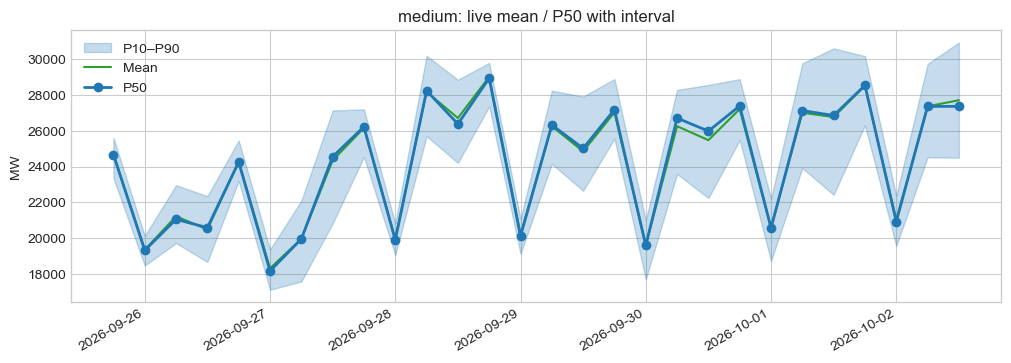

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(display_fc["timestamp"], display_fc["p10"], display_fc["p90"], color="tab:blue", alpha=0.25, label="P10–P90")
ax.plot(display_fc["timestamp"], display_fc["mean_pred"], color="tab:green", linewidth=1.5, label="Mean")
ax.plot(display_fc["timestamp"], display_fc["p50"], color="tab:blue", linewidth=2, marker="o", label="P50")
ax.set_title(f"{MODE}: live mean / P50 with interval")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Drivers for mean, P10, and P90

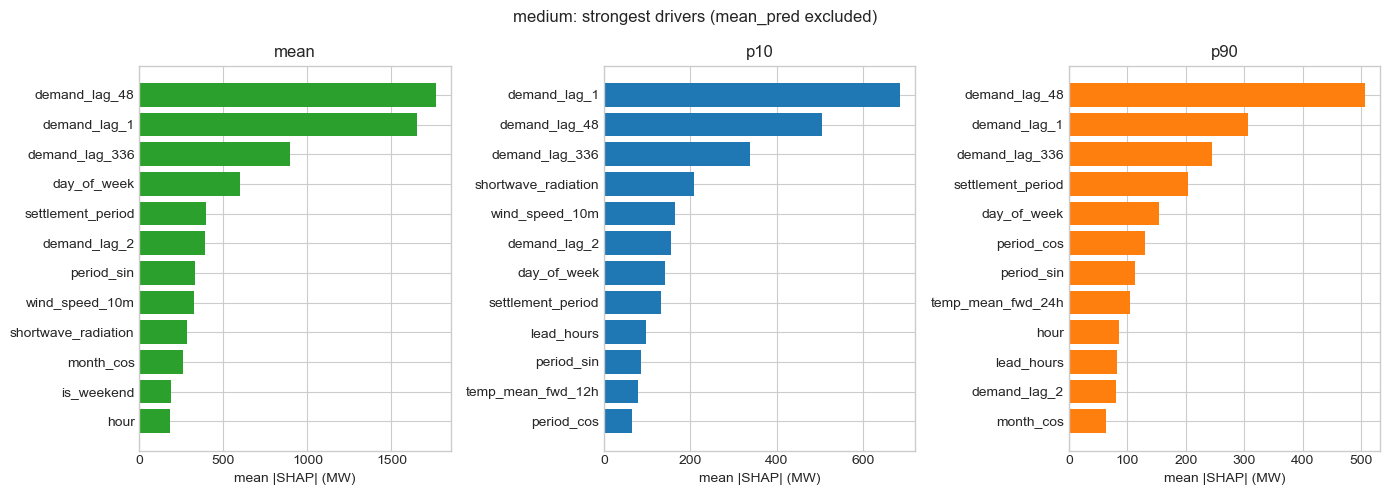

mean


,feature,mean_abs_shap
0,demand_lag_48,"1,763.89"
1,demand_lag_1,"1,651.14"
2,demand_lag_336,893.93
3,day_of_week,600.28
4,settlement_period,397.66
5,demand_lag_2,392.90
6,period_sin,329.77
7,wind_speed_10m,325.33


p10


,feature,mean_abs_shap
0,demand_lag_1,686.96
1,demand_lag_48,504.86
2,demand_lag_336,338.57
3,shortwave_radiation,208.35
4,wind_speed_10m,164.85
5,demand_lag_2,153.76
6,day_of_week,140.59
7,settlement_period,130.81


p90


,feature,mean_abs_shap
0,demand_lag_48,506.31
1,demand_lag_1,305.50
2,demand_lag_336,244.59
3,settlement_period,203.34
4,day_of_week,154.57
5,period_cos,129.58
6,period_sin,113.31
7,temp_mean_fwd_24h,104.40


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=False)
for ax, output, color in zip(axes, OUTPUTS, ["tab:green", "tab:blue", "tab:orange"]):
    ranking = mean_abs_shap(shap_by_output[output], n=12)
    ax.barh(ranking["feature"][::-1], ranking["mean_abs_shap"][::-1], color=color)
    ax.set_title(output)
    ax.set_xlabel("mean |SHAP| (MW)")
plt.suptitle(f"{MODE}: strongest drivers (mean_pred excluded)")
plt.tight_layout()
plt.show()

for output in OUTPUTS:
    print(output)
    display(mean_abs_shap(shap_by_output[output], n=8))

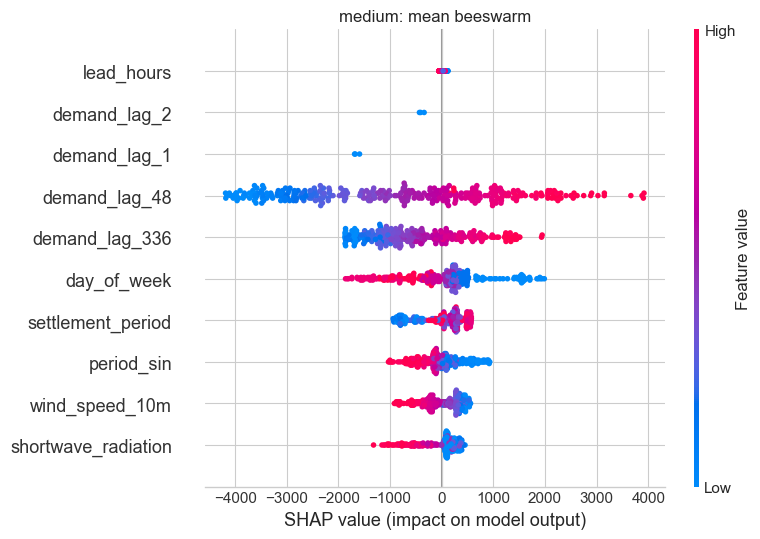

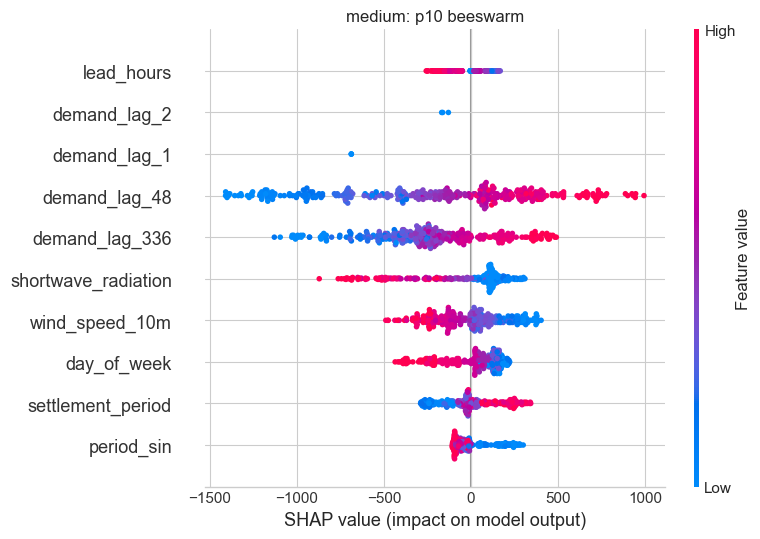

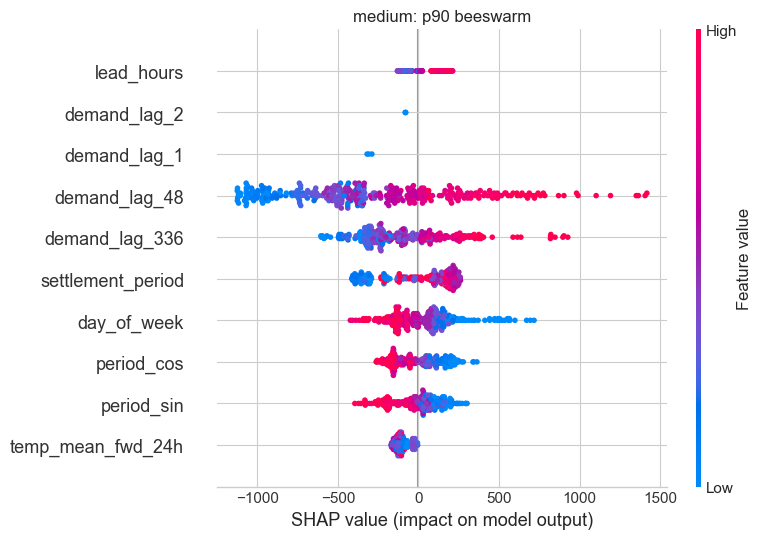

In [15]:
for output in OUTPUTS:
    shap_df = shap_by_output[output]
    feature_cols = [c for c in shap_df.columns if c != "shap_base" and c in scored.columns]
    shap.summary_plot(
        shap_df.loc[:, feature_cols].to_numpy(),
        scored.loc[:, feature_cols],
        max_display=10,
        show=False,
    )
    plt.title(f"{MODE}: {output} beeswarm")
    plt.tight_layout()
    plt.show()

## Each displayed prediction

One row per hour. Top three features for the **mean**, then for **P10** and **P90** (extra pull after the mean).

In [6]:
show = details.copy()
for col in ["mean_pred", "p10", "p50", "p90", "interval_width", "temperature_2m"]:
    if col in show.columns:
        show[col] = show[col].round(1)
for col in show.columns:
    if col.endswith("_shap"):
        show[col] = show[col].round(1)
display(show)

,timestamp,model,lead_hours,mean_pred,p10,p50,p90,interval_width,temperature_2m,n_periods,...,p10_top2,p10_top2_shap,p10_top3,p10_top3_shap,p90_top1,p90_top1_shap,p90_top2,p90_top2_shap,p90_top3,p90_top3_shap
0,2026-09-25 18:00:00+01:00,hour,0.00,"24,793.30","24,110.40","24,813.70","25,051.50",941.10,16.30,2,...,demand_lag_2,-154.10,demand_lag_48,106.00,demand_lag_1,-273.00,demand_lag_2,-92.40,demand_lag_48,59.60
1,2026-09-25 19:00:00+01:00,day,1.00,"27,517.60","26,330.40","27,574.80","28,253.50","1,923.10",15.40,2,...,demand_lag_48,229.90,demand_lag_2,-129.90,demand_lag_48,321.10,demand_lag_1,-289.20,demand_lag_336,161.40
2,2026-09-25 20:00:00+01:00,day,2.00,"28,594.50","26,906.00","28,704.70","29,758.50","2,852.50",14.90,2,...,settlement_period,110.30,month_cos,-69.00,demand_lag_48,464.80,settlement_period,90.70,demand_lag_336,87.60
3,2026-09-25 21:00:00+01:00,day,3.00,"26,643.80","24,900.80","26,716.20","27,798.70","2,897.90",14.40,2,...,settlement_period,103.20,demand_lag_336,-80.10,demand_lag_336,-124.60,demand_lag_48,99.10,settlement_period,80.90
4,2026-09-25 22:00:00+01:00,day,4.00,"23,945.10","22,275.80","23,946.30","25,074.10","2,798.30",13.80,2,...,demand_lag_336,-158.10,settlement_period,81.20,demand_lag_336,-299.70,demand_lag_48,-219.10,settlement_period,65.40
5,2026-09-25 23:00:00+01:00,day,5.00,"22,114.50","20,614.30","22,072.80","23,373.30","2,759.00",13.20,2,...,demand_lag_336,-250.30,cdd_sum_72h,-76.90,demand_lag_336,-439.90,demand_lag_48,-313.00,period_cos,-62.70
6,2026-09-26 00:00:00+01:00,day,6.00,"20,886.10","19,268.90","20,889.50","21,665.80","2,396.90",12.90,2,...,demand_lag_336,-376.10,settlement_period,-101.60,demand_lag_336,-461.60,demand_lag_48,-358.90,settlement_period,-182.40
7,2026-09-26 01:00:00+01:00,day,7.00,"20,581.50","19,185.60","20,574.40","21,371.30","2,185.70",13.30,2,...,demand_lag_48,-405.10,shortwave_radiation,104.80,demand_lag_336,-436.30,demand_lag_48,-344.00,settlement_period,-194.00
8,2026-09-26 02:00:00+01:00,day,8.00,"19,846.00","18,783.90","19,844.50","20,615.70","1,831.80",13.00,2,...,demand_lag_48,-443.10,settlement_period,-110.40,demand_lag_336,-520.00,demand_lag_48,-392.50,settlement_period,-208.30
9,2026-09-26 03:00:00+01:00,day,9.00,"18,689.20","18,184.80","18,621.80","19,467.40","1,282.60",12.90,2,...,demand_lag_336,-447.80,settlement_period,-132.50,demand_lag_336,-590.30,demand_lag_48,-447.90,settlement_period,-215.90
